In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
x = data.drop("median_house_value" , axis = 1)
y = data["median_house_value"]

In [4]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [5]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [6]:
x.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [7]:
z = x["total_bedrooms"].median()
z

435.0

In [8]:
x["total_bedrooms"].fillna(z,inplace=True)

C:\Users\kriti\AppData\Local\Temp\ipykernel_12148\1310619075.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x["total_bedrooms"].fillna(z,inplace=True)


In [9]:
x.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [10]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.4+ MB


In [11]:
x.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100


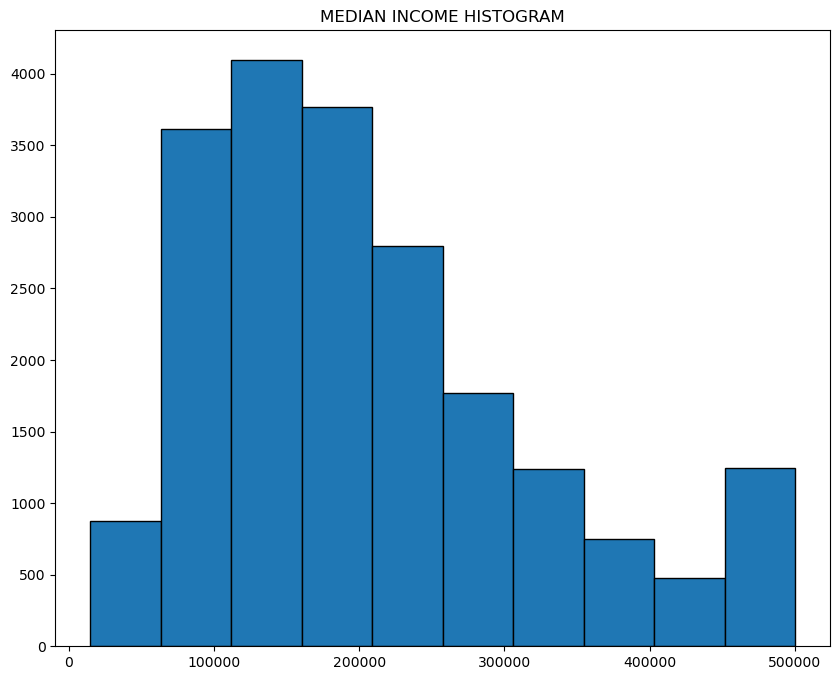

In [12]:
plt.figure(figsize=(10,8))
plt.hist(y,bins=10,edgecolor="black",)
plt.title("MEDIAN INCOME HISTOGRAM")
plt.show()

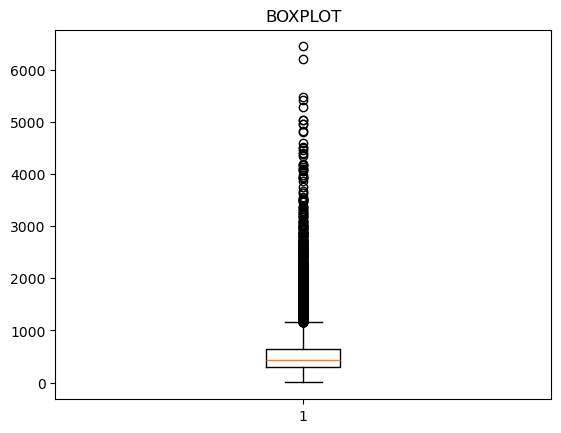

In [13]:
plt.boxplot(x["total_bedrooms"])
plt.title("BOXPLOT")
plt.show()

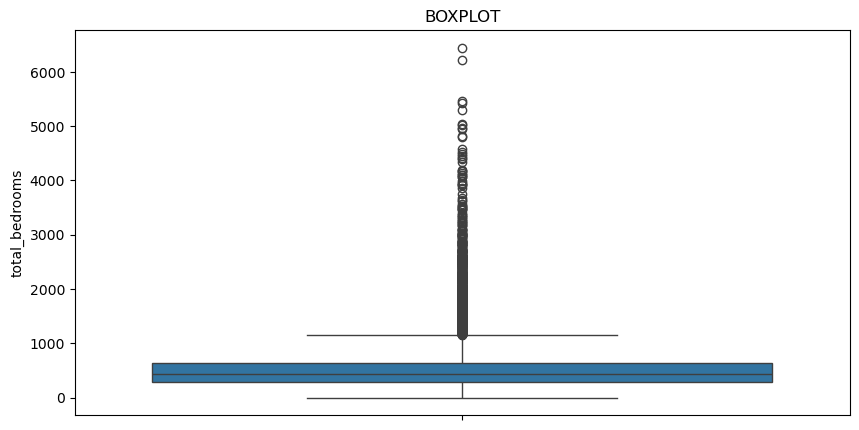

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x["total_bedrooms"])
plt.title("BOXPLOT")
plt.show()

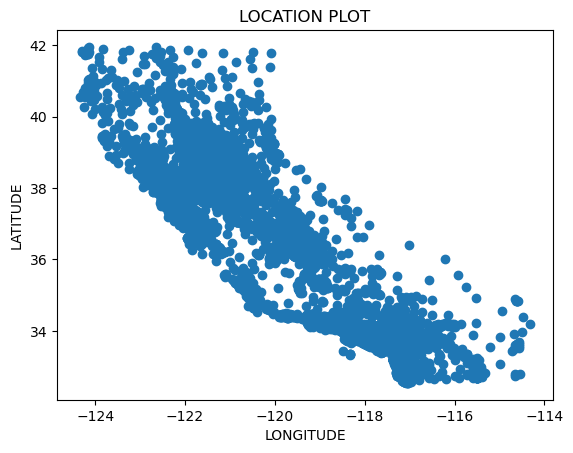

In [15]:
plt.scatter(x["longitude"],x["latitude"])
plt.title("LOCATION PLOT")
plt.xlabel("LONGITUDE")
plt.ylabel("LATITUDE")
plt.show()

In [16]:
x["bedrooms_per_room"] = x["total_bedrooms"] / x["total_rooms"]
x["population_per_household"] = x["population"] / x["households"]
x["rooms_per_household"] = x["total_rooms"] / x['households']

In [17]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,bedrooms_per_room,population_per_household,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,0.146591,2.555556,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,0.155797,2.109842,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,0.129516,2.802260,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,0.184458,2.547945,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,0.172096,2.181467,6.281853
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,0.224625,2.560606,5.045455
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,0.215208,3.122807,6.114035
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,0.215173,2.325635,5.205543
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,0.219892,2.123209,5.329513


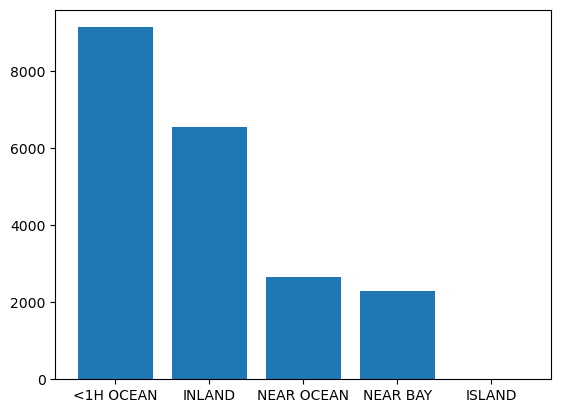

In [18]:
counts = data["ocean_proximity"].value_counts()
plt.bar(counts.index, counts.values)
plt.show()

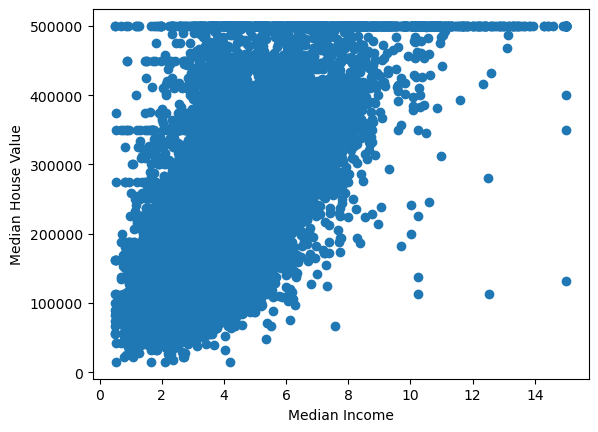

In [19]:
plt.scatter(data["median_income"], data["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

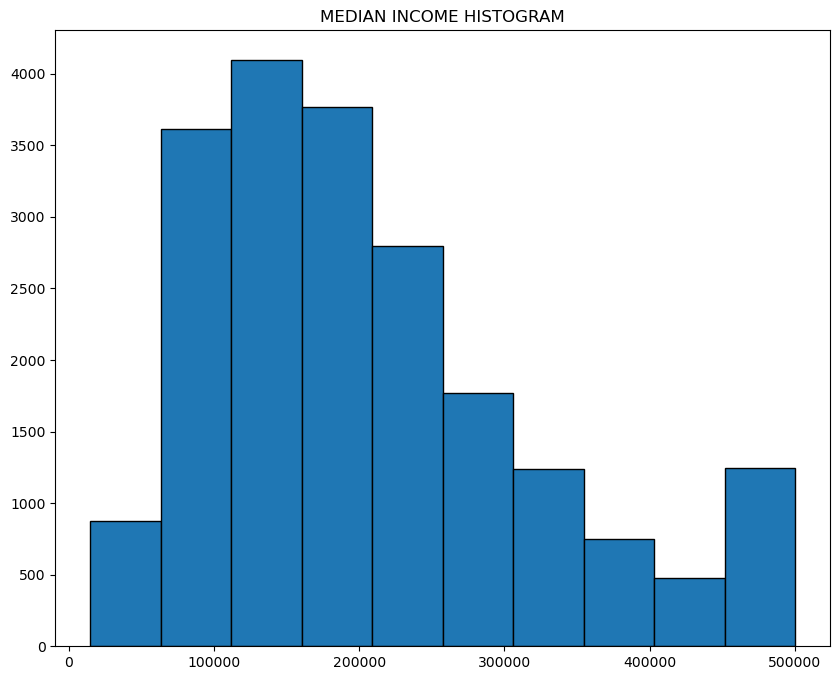

In [20]:
plt.figure(figsize=(10,8))
plt.hist(data["median_house_value"] , bins = 10 , edgecolor = "black")
plt.title("MEDIAN INCOME HISTOGRAM")
plt.show()

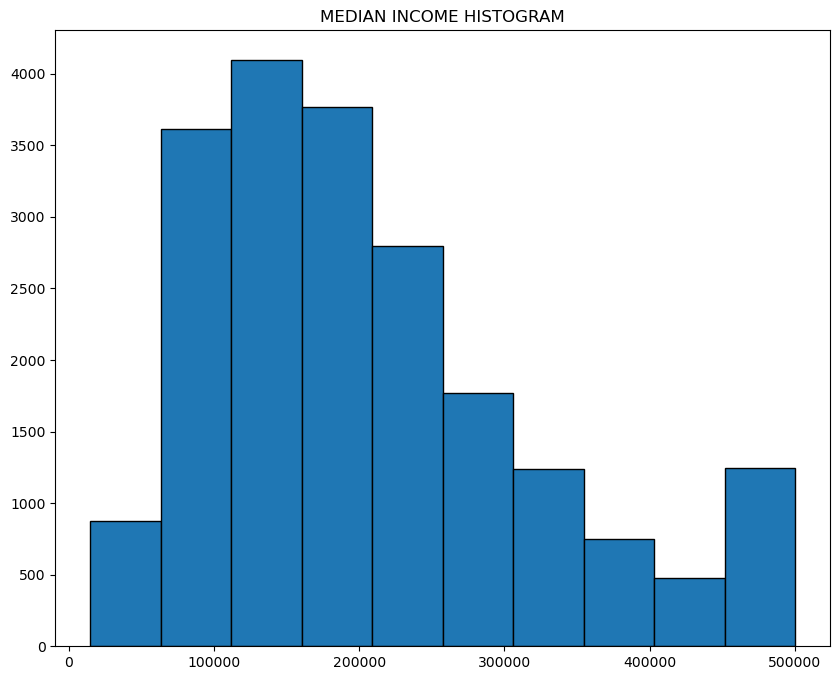

In [21]:
plt.figure(figsize=(10,8))
plt.hist(y,bins=10,edgecolor="black",)
plt.title("MEDIAN INCOME HISTOGRAM")
plt.show()

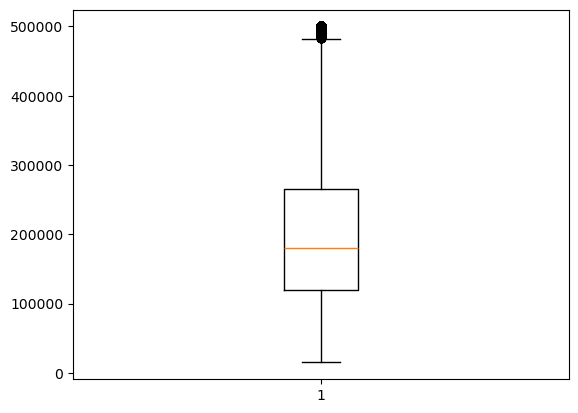

In [22]:
plt.boxplot(data["median_house_value"])
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3, stratify=x["ocean_proximity"])

In [25]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,bedrooms_per_room,population_per_household,rooms_per_household
7322,-118.17,33.98,27.0,1871.0,556.0,2542.0,581.0,2.8427,<1H OCEAN,0.297167,4.375215,3.220310
7899,-118.05,33.86,16.0,2851.0,626.0,1985.0,603.0,5.4089,<1H OCEAN,0.219572,3.291874,4.728027
16322,-121.31,37.99,15.0,3103.0,965.0,3061.0,861.0,1.3729,INLAND,0.310989,3.555168,3.603949
5211,-118.28,33.93,43.0,269.0,74.0,295.0,79.0,2.2969,<1H OCEAN,0.275093,3.734177,3.405063
1561,-121.96,37.76,8.0,3865.0,463.0,1548.0,432.0,9.7037,<1H OCEAN,0.119793,3.583333,8.946759
...,...,...,...,...,...,...,...,...,...,...,...,...
17359,-120.41,34.88,4.0,3680.0,559.0,1678.0,569.0,5.0639,<1H OCEAN,0.151902,2.949033,6.467487
4374,-118.28,34.10,49.0,1767.0,467.0,1066.0,438.0,3.0958,<1H OCEAN,0.264290,2.433790,4.034247
15774,-122.45,37.76,52.0,1457.0,292.0,621.0,315.0,4.6477,NEAR BAY,0.200412,1.971429,4.625397
2354,-119.69,36.79,5.0,2613.0,476.0,1490.0,481.0,4.0993,INLAND,0.182166,3.097713,5.432432


In [26]:
y_train

7322     164400.0
7899     265600.0
16322    110300.0
5211      90600.0
1561     425100.0
           ...   
17359    201700.0
4374     210900.0
15774    450000.0
2354      83000.0
19554     54100.0
Name: median_house_value, Length: 14448, dtype: float64

In [27]:
x_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,bedrooms_per_room,population_per_household,rooms_per_household
16261,-121.26,37.96,35.0,1511.0,316.0,892.0,304.0,1.7898,INLAND,0.209133,2.934211,4.970395
9856,-121.86,36.58,20.0,6332.0,991.0,2668.0,955.0,5.7578,<1H OCEAN,0.156507,2.793717,6.630366
9553,-120.64,37.38,21.0,3157.0,637.0,2268.0,620.0,2.5670,INLAND,0.201774,3.658065,5.091935
16615,-120.92,35.40,23.0,2059.0,354.0,636.0,278.0,3.6908,NEAR OCEAN,0.171928,2.287770,7.406475
7991,-118.17,33.86,40.0,1301.0,342.0,954.0,336.0,2.3804,<1H OCEAN,0.262875,2.839286,3.872024
...,...,...,...,...,...,...,...,...,...,...,...,...
16361,-121.30,38.01,29.0,2289.0,449.0,1215.0,435.0,3.2788,INLAND,0.196156,2.793103,5.262069
12003,-117.57,33.90,7.0,3797.0,850.0,2369.0,720.0,3.5525,INLAND,0.223861,3.290278,5.273611
3273,-122.92,39.05,16.0,1548.0,295.0,605.0,250.0,3.5652,INLAND,0.190568,2.420000,6.192000
4019,-118.49,34.18,31.0,3073.0,674.0,1486.0,684.0,4.8984,<1H OCEAN,0.219330,2.172515,4.492690


In [28]:
y_test

16261     63500.0
9856     347700.0
9553      70400.0
16615    278800.0
7991     158000.0
           ...   
16361    100000.0
12003    137600.0
3273     119000.0
4019     311700.0
12235     94500.0
Name: median_house_value, Length: 6192, dtype: float64

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , StandardScaler

In [30]:
num_cols = x.select_dtypes(["int","float"]).columns
cat_cols = x.select_dtypes("object").columns
cat_cols

Index(['ocean_proximity'], dtype='object')

In [31]:
num_pipeline = Pipeline(
    steps=[("impute",SimpleImputer(strategy="median")),
    ("scale",StandardScaler())]
)
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())])

In [32]:
cat_pipeline = Pipeline(
    steps=[("encode",OneHotEncoder())]
)
cat_pipeline

Pipeline(steps=[('encode', OneHotEncoder())])

In [33]:
col_trans = ColumnTransformer(
    transformers=[("num",num_pipeline,num_cols),
        ("cat",cat_pipeline,cat_cols)]
)
col_trans

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('encode', OneHotEncoder())]),
                                 Index(['ocean_proximity'], dtype='object'))])

In [34]:
col_trans.fit_transform(x_train)

array([[ 0.69808605, -0.77172016, -0.12766622, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.75800966, -0.82788151, -0.99936828, ...,  0.        ,
         0.        ,  0.        ],
       [-0.86991503,  1.10500524, -1.07861392, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.43918931,  0.99736264,  1.85347483, ...,  0.        ,
         1.        ,  0.        ],
       [-0.06094632,  0.54339166, -1.87107034, ...,  0.        ,
         0.        ,  0.        ],
       [-0.71011874,  0.93184106,  0.6647902 , ...,  0.        ,
         0.        ,  0.        ]])

In [35]:
final_pipeline = Pipeline(
    steps=[
        ("preprocess" , col_trans),
        ("model" , LinearRegression())
    ]
)
final_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder())]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('model', LinearRegression())])

In [36]:
final_pipeline.fit(x_train ,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder())]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('model', LinearRegression())])

In [37]:
y_pred = final_pipeline.predict(x_test)
y_pred

array([ 85944.77351264, 326602.73533065,  80982.31997485, ...,
       158668.25463547, 292024.60463942, 122587.22742797])

In [38]:
from sklearn.metrics import r2_score

In [39]:
r2_score(y_test , y_pred)

0.6461146566053158

In [40]:
r2_score(y_test , y_pred)*100

64.61146566053158

In [41]:
 from sklearn.ensemble import RandomForestRegressor

In [42]:
final_pipeline = Pipeline(
    steps=[
        ("preprocess" , col_trans),
        ("model" , RandomForestRegressor())
    ]
)
final_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder())]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('model', RandomForestRegressor())])

In [43]:
final_pipeline.fit(x_train , y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder())]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('model', RandomForestRegressor())])

In [44]:
y_pred = final_pipeline.predict(x_test)
y_pred

array([ 66269.  , 318366.02,  86610.  , ..., 174895.  , 354713.04,
       111117.  ])

In [45]:
r2_score(y_test , y_pred)

0.8118278511331108

In [46]:
r2_score(y_test , y_pred)*100

81.18278511331108

In [47]:
from sklearn.model_selection import cross_validate 

In [48]:
cross_validate(final_pipeline , x_train , y_train , cv=5 , scoring="r2")

{'fit_time': array([20.02257848, 19.91819167, 19.76622581, 19.91386819, 20.44228649]),
 'score_time': array([0.13453531, 0.12509823, 0.1209681 , 0.12446642, 0.1329565 ]),
 'test_score': array([0.79327959, 0.80797047, 0.80404782, 0.81640007, 0.79889256])}